# 00. Kiểm tra bộ dữ liệu ViMMSD

Kiểm tra dữ liệu trước khi viết pipeline: cấu trúc thư mục, định dạng annotation, ảnh thiếu/lỗi, phân bố nhãn,
đặc điểm caption, dữ liệu trùng lặp, và đối chiếu với `configs/base.yaml`.

**Notebook này chạy độc lập, không cần clone repo.** Trên Kaggle: *Add Input* → dataset
[`hhhoang/vimmsd-dataset`](https://www.kaggle.com/datasets/hhhoang/vimmsd-dataset), không cần GPU, không cần Internet.
Chạy local: đặt dữ liệu vào `data/raw/`.

Kết quả tóm tắt được lưu vào `dataset_check.json` (trong `/kaggle/working` trên Kaggle).

In [1]:
import collections
import hashlib
import html
import itertools
import json
import re
import unicodedata
import warnings
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")  # emoji trong tiêu đề hình
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

LABELS = ["not-sarcasm", "text-sarcasm", "image-sarcasm", "multi-sarcasm"]
# (file annotation, thư mục ảnh), phải khớp với mục `data` trong configs/base.yaml
SPLITS = {
    "train": ("vimmsd-train.json", "training-images/train-images"),
    "public_test": ("vimmsd-public-test.json", "public-test-images/dev-images"),
    "private_test": ("vimmsd-private-test.json", "private-test-images/test-images"),
}
TEST_SPLITS = [s for s in SPLITS if s != "train"]

DATA_DIR = None       # None = tự tìm thư mục chứa vimmsd-train.json
SEARCH_ROOTS = ["/kaggle/input", "data/raw", "../data/raw"]
HASH_IMAGES = True    # tính md5 mọi ảnh để tìm ảnh trùng (đọc ~1GB, vài phút)
OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

checks = []  # bảng tổng hợp ở cuối notebook


def check(name, ok, detail=""):
    checks.append({"kiểm tra": name, "kết quả": "OK" if ok else "CHÚ Ý", "chi tiết": detail})
    print(("OK    " if ok else "CHÚ Ý ") + name + (f"  ({detail})" if detail else ""))

## 1. Tìm thư mục dữ liệu và xem cấu trúc

In [2]:
def find_data_dir():
    if DATA_DIR:
        return Path(DATA_DIR)
    for root in map(Path, SEARCH_ROOTS):
        if root.exists():
            hits = sorted(root.rglob("vimmsd-train.json"))
            if hits:
                return hits[0].parent
    raise FileNotFoundError("Không tìm thấy vimmsd-train.json. Trên Kaggle: Add Input -> hhhoang/vimmsd-dataset")


data_dir = find_data_dir()
print("data_dir =", data_dir)

rows = []
for p in sorted(data_dir.rglob("*")):
    if p.is_dir():
        files = [f for f in p.iterdir() if f.is_file()]
        if files:
            rows.append({"đường dẫn": str(p.relative_to(data_dir)) + "/", "số file": len(files),
                         "MB": round(sum(f.stat().st_size for f in files) / 1e6, 1),
                         "đuôi file": dict(collections.Counter(f.suffix.lower() for f in files))})
    elif p.parent == data_dir:
        rows.append({"đường dẫn": p.name, "số file": 1, "MB": round(p.stat().st_size / 1e6, 2),
                     "đuôi file": {p.suffix.lower(): 1}})
display(pd.DataFrame(rows))

data_dir = /kaggle/input/datasets/hhhoang/vimmsd-dataset


,đường dẫn,số file,MB,đuôi file
0,private-test-images/test-images/,1504,81.10,{'.jpg': 1504}
1,public-test-images/dev-images/,1413,81.70,{'.jpg': 1413}
2,training-images/train-images/,10805,864.60,{'.jpg': 10805}
3,vimmsd-private-test.json,1,0.49,{'.json': 1}
4,vimmsd-public-test.json,1,0.44,{'.json': 1}
5,vimmsd-train.json,1,5.05,{'.json': 1}


## 2. Đọc annotation và kiểm tra định dạng

In [3]:
dfs = {}
for split, (json_name, image_dir) in SPLITS.items():
    path = data_dir / json_name
    check(f"có file {json_name}", path.exists())
    if not path.exists():
        continue
    raw = json.loads(path.read_text(encoding="utf-8"))
    values = list(raw.values()) if isinstance(raw, dict) else raw
    key_sets = collections.Counter(tuple(sorted(v)) for v in values)
    print(f"   {split}: kiểu {type(raw).__name__}, {len(raw)} mẫu, các bộ key: {dict(key_sets)}")
    check(f"{split}: mọi mẫu có đủ image/caption/label", set(key_sets) == {("caption", "image", "label")},
          str(dict(key_sets)))
    items = raw.items() if isinstance(raw, dict) else enumerate(raw)
    df = pd.DataFrame([{"id": str(k), **v} for k, v in items])
    df["split"] = split
    df["image_path"] = [str(data_dir / image_dir / name) for name in df["image"]]
    dfs[split] = df

train = dfs["train"]
for split, df in dfs.items():
    print(f"\n{split}:")
    display(df.head(3)[["id", "image", "caption", "label"]])

OK    có file vimmsd-train.json
   train: kiểu dict, 10805 mẫu, các bộ key: {('caption', 'image', 'label'): 10805}
OK    train: mọi mẫu có đủ image/caption/label  ({('caption', 'image', 'label'): 10805})
OK    có file vimmsd-public-test.json
   public_test: kiểu dict, 1413 mẫu, các bộ key: {('caption', 'image', 'label'): 1413}
OK    public_test: mọi mẫu có đủ image/caption/label  ({('caption', 'image', 'label'): 1413})
OK    có file vimmsd-private-test.json
   private_test: kiểu dict, 1504 mẫu, các bộ key: {('caption', 'image', 'label'): 1504}
OK    private_test: mọi mẫu có đủ image/caption/label  ({('caption', 'image', 'label'): 1504})

train:


,id,image,caption,label
0,0,8ae451edcd8ebf697f8763ece249115813149c55733bf8306b971210d48b15d3.jpg,Cô ấy trên mạng vs cô ấy ngoài đời =))),multi-sarcasm
1,1,35370ffd6c791d6f8c4ab3dd4363ed468fab41e4824ee9984169f58be672a0b7.jpg,Người tâm linh giao tiếp với người thực tế :))),not-sarcasm
2,2,316fdd1477725b9fb1a55015ac06b68b92b50bd4303e08590dadedace629ae61.jpg,Hình như Trăng hôm nay đẹp quá mọi người ạ! 😃 😃\n#canhco,multi-sarcasm



public_test:


,id,image,caption,label
0,0,bb934d7d7f7652903c24272d405e4b31c70689cec93f86d5d36f17707c36fceb.jpg,"Hãy thực tế lên, đừng kêu ca nữa :)))",None
1,1,449a108232be3d220679d7c500ee0aa3203920c01163190bf900456af85564f6.jpg,Thôi thế cho anh mua gói lạc,None
2,2,2c17cee0245711376b566a65d1a9d25066317fc894fc0a7a98543dada5883e1b.jpg,Chính quyền bang và đơn vị vận hành lưới điện đang vật lộn với tình thế kỳ quặc. Quá nhiều điện mặt trời vào những n...,None



private_test:


,id,image,caption,label
0,0,066d6021fdfeaf39f1dec523879e8fe4d35e877abcea44c428d45e1b81554444.jpg,Song Joong Ki &amp; Song Hye Kyo đều tham dự Baeksang 2024 với 2 vai trò khác nhau và không chung khung hình. Nữ chí...,None
1,1,555f4787d4df49e7be743b3d5b77c90755f0d6c351f36b02c364775d5929b7c4.jpg,Song Joong Ki &amp; Song Hye Kyo đều tham dự Baeksang 2024 với 2 vai trò khác nhau và không chung khung hình. Nữ chí...,None
2,2,7b7cdea2cde1f3f93371259b587a03f2e8c0af682b4d519ef752706d83627d2c.jpg,Song Joong Ki &amp; Song Hye Kyo đều tham dự Baeksang 2024 với 2 vai trò khác nhau và không chung khung hình. Nữ chí...,None


In [4]:
check("train: id không trùng", train["id"].is_unique)
check("train: không có nhãn rỗng", train["label"].notna().all(), f"{train['label'].isna().sum()} mẫu rỗng")
unknown = set(train["label"].dropna()) - set(LABELS)
check("train: nhãn thuộc 4 lớp đã biết", not unknown, f"nhãn lạ: {unknown}" if unknown else "")
for split in TEST_SPLITS:
    if split in dfs:
        vc = dfs[split]["label"].value_counts(dropna=False).to_dict()
        check(f"{split}: không có nhãn (label = null)", dfs[split]["label"].isna().all(), str(vc))
for split, df in dfs.items():
    is_str = df["caption"].map(lambda x: isinstance(x, str))
    check(f"{split}: caption là chuỗi", is_str.all(), f"{(~is_str).sum()} mẫu không phải chuỗi")
    empty = df["caption"].fillna("").str.strip() == ""
    check(f"{split}: không có caption rỗng", not empty.any(), f"{empty.sum()} mẫu rỗng")

OK    train: id không trùng
OK    train: không có nhãn rỗng  (0 mẫu rỗng)
OK    train: nhãn thuộc 4 lớp đã biết
OK    public_test: không có nhãn (label = null)  ({None: 1413})
OK    private_test: không có nhãn (label = null)  ({None: 1504})
OK    train: caption là chuỗi  (0 mẫu không phải chuỗi)
OK    train: không có caption rỗng  (0 mẫu rỗng)
OK    public_test: caption là chuỗi  (0 mẫu không phải chuỗi)
OK    public_test: không có caption rỗng  (0 mẫu rỗng)
OK    private_test: caption là chuỗi  (0 mẫu không phải chuỗi)
OK    private_test: không có caption rỗng  (0 mẫu rỗng)


## 3. Đối chiếu annotation với file ảnh

In [5]:
for split, (_, image_dir) in SPLITS.items():
    if split not in dfs:
        continue
    folder = data_dir / image_dir
    check(f"{split}: có thư mục {image_dir}", folder.exists())
    on_disk = {f.name for f in folder.iterdir()} if folder.exists() else set()
    referenced = set(dfs[split]["image"])
    missing, orphan = referenced - on_disk, on_disk - referenced
    check(f"{split}: mọi ảnh trong JSON đều có file", not missing, f"thiếu {len(missing)}/{len(referenced)}")
    check(f"{split}: không có file ảnh thừa", not orphan, f"{len(orphan)} file không có trong JSON")
    check(f"{split}: mỗi ảnh chỉ thuộc 1 mẫu", dfs[split]["image"].is_unique,
          f"{dfs[split]['image'].duplicated().sum()} tên ảnh lặp")
    dfs[split]["exists"] = dfs[split]["image"].isin(on_disk)

names = {s: set(df["image"]) for s, df in dfs.items()}
for a, b in itertools.combinations(dfs, 2):
    common = names[a] & names[b]
    check(f"không trùng tên ảnh giữa {a} và {b}", not common, f"{len(common)} ảnh")

df_all = pd.concat(dfs.values(), ignore_index=True)
train = dfs["train"]

OK    train: có thư mục training-images/train-images
OK    train: mọi ảnh trong JSON đều có file  (thiếu 0/10805)
OK    train: không có file ảnh thừa  (0 file không có trong JSON)
OK    train: mỗi ảnh chỉ thuộc 1 mẫu  (0 tên ảnh lặp)
OK    public_test: có thư mục public-test-images/dev-images
OK    public_test: mọi ảnh trong JSON đều có file  (thiếu 0/1413)
OK    public_test: không có file ảnh thừa  (0 file không có trong JSON)
OK    public_test: mỗi ảnh chỉ thuộc 1 mẫu  (0 tên ảnh lặp)
OK    private_test: có thư mục private-test-images/test-images
OK    private_test: mọi ảnh trong JSON đều có file  (thiếu 0/1504)
OK    private_test: không có file ảnh thừa  (0 file không có trong JSON)
OK    private_test: mỗi ảnh chỉ thuộc 1 mẫu  (0 tên ảnh lặp)
OK    không trùng tên ảnh giữa train và public_test  (0 ảnh)
OK    không trùng tên ảnh giữa train và private_test  (0 ảnh)
OK    không trùng tên ảnh giữa public_test và private_test  (0 ảnh)


## 4. Phân bố nhãn (train)

,số mẫu,tỉ lệ %,≈ val 10%,≈ test 10%
label,,,,
not-sarcasm,6062,56.10,606,606
text-sarcasm,77,0.71,8,8
image-sarcasm,442,4.09,44,44
multi-sarcasm,4224,39.09,422,422


lớp nhiều nhất / ít nhất = 78.7 lần
OK    mọi lớp có >= 50 mẫu  (ít nhất: text-sarcasm = 77)


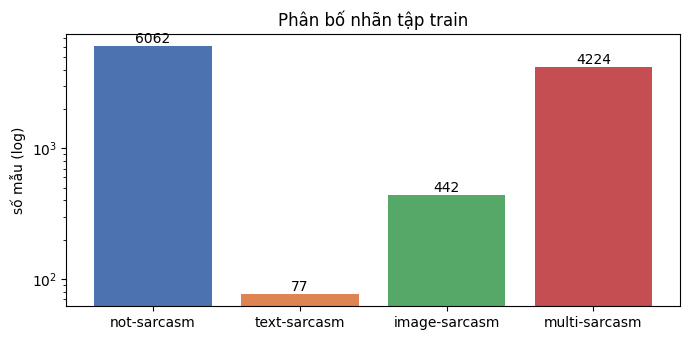

In [6]:
counts = train["label"].value_counts().reindex(LABELS).fillna(0).astype(int)
dist = pd.DataFrame({"số mẫu": counts, "tỉ lệ %": (100 * counts / counts.sum()).round(2)})
# config mặc định chia stratified 80/10/10 từ train (test công khai không có nhãn)
dist["≈ val 10%"] = (counts * 0.1).round().astype(int)
dist["≈ test 10%"] = (counts * 0.1).round().astype(int)
display(dist)
print(f"lớp nhiều nhất / ít nhất = {counts.max() / max(counts.min(), 1):.1f} lần")
check("mọi lớp có >= 50 mẫu", counts.min() >= 50, f"ít nhất: {counts.idxmin()} = {counts.min()}")

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(LABELS, counts.values, color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
ax.bar_label(bars)
ax.set_yscale("log")
ax.set_ylabel("số mẫu (log)")
ax.set_title("Phân bố nhãn tập train")
plt.tight_layout()
plt.show()

## 5. Caption: độ dài

Theo split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
private_test,1504.0,27.7,61.4,1.0,5.0,8.0,18.0,513.0
public_test,1413.0,26.1,62.1,1.0,5.0,8.0,16.0,708.0
train,10805.0,50.7,81.0,1.0,7.0,15.0,54.0,846.0


Train theo nhãn:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
not-sarcasm,6062.0,72.0,93.7,1.0,10.0,25.0,107.0,846.0
text-sarcasm,77.0,45.7,68.3,1.0,6.0,17.0,39.0,348.0
image-sarcasm,442.0,32.8,68.0,1.0,3.0,8.0,21.0,488.0
multi-sarcasm,4224.0,22.2,45.9,1.0,5.0,9.0,17.0,800.0


caption > 64 từ: 20.0%
caption > 90 từ: 16.1%
caption > 128 từ: 12.0%


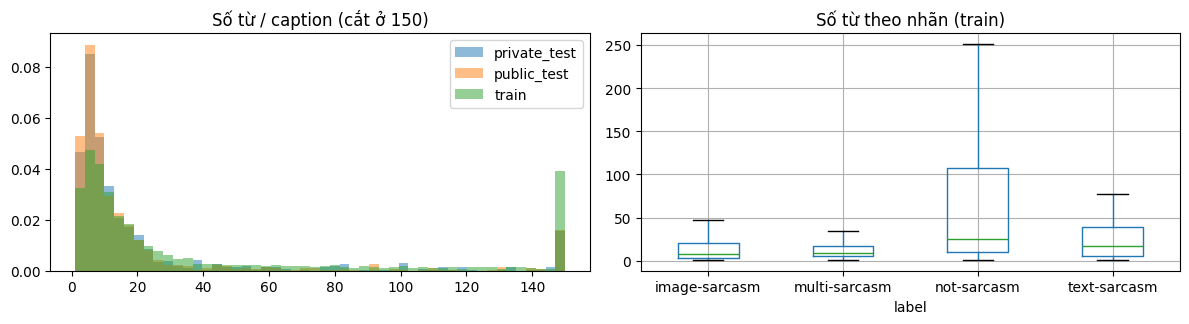

Caption dài nhất:


,split,label,n_words,caption
8098,train,not-sarcasm,846,"Thoát đột tử do đột quỵ, nhồi máu cơ tim, nhờ cấp cứu ngoại viện ở khung “giờ vàng”\n2h sáng lên cơn nhồi máu cơ tim..."
8138,train,not-sarcasm,828,"Các yếu tố quan trọng tăng cơ hội sống sót cho bệnh nhân nhồi máu cơ tim, đột quỵ\n“50% người bệnh nhồi máu cơ tim c..."
10660,train,not-sarcasm,800,"TIN TƯỞNG GIAO CHÌA KHOÁ CHO MÔI GIỚI, CÔ GÁI GẶP NGAY TÊN STALKER LẺN VÀO NHÀ!\nĐó là tình trạng đáng báo động của ..."


In [7]:
df_all["n_chars"] = df_all["caption"].str.len()
df_all["n_words"] = df_all["caption"].str.split().str.len()
df_all["n_lines"] = df_all["caption"].str.count("\n") + 1
train = df_all[df_all["split"] == "train"]

print("Theo split:")
display(df_all.groupby("split")["n_words"].describe().round(1))
print("Train theo nhãn:")
display(train.groupby("label")["n_words"].describe().reindex(LABELS).round(1))

# PhoBERT tối đa 256 token, config dùng max_length=128; 1 từ ≈ 1.3-1.5 subword (ước lượng thô)
for n in (64, 90, 128):
    print(f"caption > {n} từ: {(df_all['n_words'] > n).mean() * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for split, df in df_all.groupby("split"):
    axes[0].hist(df["n_words"].clip(upper=150), bins=50, alpha=0.5, density=True, label=split)
axes[0].set_title("Số từ / caption (cắt ở 150)")
axes[0].legend()
train.boxplot(column="n_words", by="label", ax=axes[1], showfliers=False)
axes[1].set_title("Số từ theo nhãn (train)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("Caption dài nhất:")
display(df_all.nlargest(3, "n_words")[["split", "label", "n_words", "caption"]])

## 6. Caption: hiện tượng cần tiền xử lý

In [8]:
EMOJI_RE = r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]"
PATTERNS = {
    "HTML entity (&amp; ...)": r"&(?:[a-zA-Z]+|#\d+);",
    "URL": r"https?://|www\.",
    "hashtag": r"#\w+",
    "mention @": r"@\w+",
    "emoji": EMOJI_RE,
    "emoticon (=))) :)))": r"[=:;]+[)(DdPp]{2,}",
    "chữ lặp (quáaaa)": r"([^\W\d_])\1{2,}",
    "xuống dòng": r"\n",
}
flags = pd.DataFrame({name: df_all["caption"].str.contains(p, regex=True) for name, p in PATTERNS.items()})
flags["Unicode chưa chuẩn NFC"] = df_all["caption"].map(lambda t: unicodedata.normalize("NFC", t) != t)
flags["split"], flags["label"] = df_all["split"], df_all["label"]

print("% caption có hiện tượng, theo split:")
display((flags.groupby("split").mean(numeric_only=True).T * 100).round(1))
print("% caption có hiện tượng, train theo nhãn:")
display((flags[flags["split"] == "train"].groupby("label").mean(numeric_only=True).T[LABELS] * 100).round(1))

entity_rows = df_all[flags["HTML entity (&amp; ...)"]]
entities = collections.Counter(m for t in entity_rows["caption"] for m in re.findall(PATTERNS["HTML entity (&amp; ...)"], t))
check("caption không chứa HTML entity", entity_rows.empty,
      f"{len(entity_rows)} caption, cần html.unescape: {dict(entities.most_common(5))}")
check("caption đã chuẩn Unicode NFC", not flags["Unicode chưa chuẩn NFC"].any(),
      f"{flags['Unicode chưa chuẩn NFC'].sum()} caption")
if not entity_rows.empty:
    ex = entity_rows["caption"].iloc[0][:150]
    print("\nví dụ:", ex, "\n  ->", html.unescape(ex))

emoji_counts = collections.Counter(e for t in df_all["caption"] for e in re.findall(EMOJI_RE, t))
print("\nemoji phổ biến:", emoji_counts.most_common(25))

% caption có hiện tượng, theo split:


split,private_test,public_test,train
HTML entity (&amp; ...),1.7,1.6,2.1
URL,8.8,7.0,1.7
hashtag,20.9,21.3,22.4
mention @,0.0,0.0,0.3
emoji,19.2,17.3,30.7
emoticon (=))) :))),24.3,25.5,7.9
chữ lặp (quáaaa),3.1,3.4,4.3
xuống dòng,35.1,34.3,53.3
Unicode chưa chuẩn NFC,0.7,0.4,0.5


% caption có hiện tượng, train theo nhãn:


label,not-sarcasm,text-sarcasm,image-sarcasm,multi-sarcasm
HTML entity (&amp; ...),2.8,6.5,3.2,0.7
URL,2.1,0.0,4.5,0.9
hashtag,20.3,22.1,37.6,23.8
mention @,0.5,0.0,0.0,0.0
emoji,33.7,29.9,25.6,26.8
emoticon (=))) :))),5.7,18.2,9.7,10.8
chữ lặp (quáaaa),5.0,2.6,3.8,3.5
xuống dòng,61.6,54.5,55.4,41.3
Unicode chưa chuẩn NFC,0.8,0.0,0.2,0.1


CHÚ Ý caption không chứa HTML entity  (271 caption, cần html.unescape: {'&amp;': 260, '&gt;': 80, '&lt;': 37})
CHÚ Ý caption đã chuẩn Unicode NFC  (72 caption)

ví dụ: “lớp du tu dờ mun” &amp; cant back.
 #CellphoneS #galaxys23ultra 
  -> “lớp du tu dờ mun” & cant back.
 #CellphoneS #galaxys23ultra

emoji phổ biến: [('❤', 435), ('🔥', 359), ('🤣', 247), ('🥰', 203), ('😍', 198), ('🏻', 194), ('👉', 170), ('🇳', 164), ('🇻', 161), ('😎', 154), ('🥹', 151), ('🥲', 144), ('😂', 128), ('👍', 128), ('👇', 118), ('♥', 117), ('💀', 110), ('🐧', 106), ('🙂', 97), ('😭', 87), ('✨', 87), ('😘', 79), ('✅', 78), ('🙏', 67), ('🥳', 67)]


## 7. Caption trùng lặp

Caption trùng với ảnh khác nhau là bình thường (cùng một câu dùng cho nhiều meme), nhưng cần biết:
- caption trùng mà **nhãn khác nhau**: model chỉ dùng text không thể phân biệt, phải nhìn ảnh;
- caption trùng **giữa train và test**: nếu chia val/test ngẫu nhiên, text của mẫu test có thể đã xuất hiện trong train
  (rò rỉ), làm điểm val/test cao hơn thực tế.

In [9]:
dup = train[train.duplicated("caption", keep=False)]
groups = dup.groupby("caption")
n_labels = groups["label"].nunique()
check("train: không có caption trùng", dup.empty,
      f"{len(dup)} mẫu ({100 * len(dup) / len(train):.1f}%) thuộc {groups.ngroups} nhóm caption trùng")
check("train: caption trùng có cùng nhãn", (n_labels <= 1).all(),
      f"{(n_labels > 1).sum()} nhóm có nhãn khác nhau")

summary = groups.agg(n=("label", "size"), labels=("label", lambda s: dict(collections.Counter(s))))
print("Các nhóm caption trùng lớn nhất:")
display(summary.sort_values("n", ascending=False).head(15))

# nếu chỉ tra bảng caption -> nhãn phổ biến nhất trong nhóm, đúng được bao nhiêu mẫu trùng?
majority = groups["label"].agg(lambda s: s.value_counts().iloc[0]).sum()
print(f"Trong các mẫu có caption trùng, đoán theo nhãn phổ biến nhất của nhóm đúng {100 * majority / len(dup):.1f}%")

train_caps = set(train["caption"])
for split in TEST_SPLITS:
    if split in dfs:
        overlap = dfs[split]["caption"].isin(train_caps)
        print(f"{split}: {overlap.sum()}/{len(overlap)} ({100 * overlap.mean():.1f}%) caption đã xuất hiện trong train")

CHÚ Ý train: không có caption trùng  (2860 mẫu (26.5%) thuộc 697 nhóm caption trùng)
CHÚ Ý train: caption trùng có cùng nhãn  (123 nhóm có nhãn khác nhau)
Các nhóm caption trùng lớn nhất:


,n,labels
caption,,
:)),34,"{'multi-sarcasm': 12, 'not-sarcasm': 11, 'image-sarcasm': 11}"
- Elsa\n#interpool #WMO #WorldMemeOrganization,24,"{'not-sarcasm': 2, 'multi-sarcasm': 1, 'image-sarcasm': 21}"
-kem,23,"{'multi-sarcasm': 7, 'image-sarcasm': 13, 'not-sarcasm': 2, 'text-sarcasm': 1}"
"Xiumin (EXO) đã hạ cánh tại Sân bay nội bài trưa nay, sẵn sàng cho Đại nhạc hội tối mai ở Thành phố Đảo Hoàng Gia Vinhomes Royal Island (Vũ Yên, Hải Phòng) \nHà Nội đón Xiumin bằng thời tiết mát lạnh, sáng nay mưa mà đến giờ hạ cánh lại hửng nắng tạnh ngay. \nĐược biết là từ Nội Bài, Xiumin sẽ di chuyển về Hải Phòng, tổng duyệt tại Vinhomes Royal Island vào 10h sáng 1/6; trình diễn chính thức vào khoảng 20h tối 1/6 cùng ngày.",10,{'not-sarcasm': 10}
=)),8,"{'multi-sarcasm': 6, 'image-sarcasm': 2}"
Ủa,7,"{'multi-sarcasm': 6, 'image-sarcasm': 1}"
-kem-\n#interpool,6,"{'image-sarcasm': 4, 'not-sarcasm': 1, 'multi-sarcasm': 1}"
😭😭😭,6,"{'multi-sarcasm': 4, 'image-sarcasm': 2}"
"Iphone 14 chính thức lộ diện, người hạnh phúc nhất lúc này là các anh chồng, vì sắp được tặng con 13 của vợ rồi \n#CellphoneS #iPhone14 #iPhone",5,"{'text-sarcasm': 3, 'not-sarcasm': 2}"


Trong các mẫu có caption trùng, đoán theo nhãn phổ biến nhất của nhóm đúng 93.6%
public_test: 52/1413 (3.7%) caption đã xuất hiện trong train
private_test: 68/1504 (4.5%) caption đã xuất hiện trong train


## 8. Kiểm tra file ảnh

Mở toàn bộ ảnh: ảnh lỗi, định dạng thật so với đuôi file, chế độ màu, kích thước, ảnh trùng (md5).

In [10]:
records = []
for split, df in dfs.items():
    for row in tqdm(df[df["exists"]].itertuples(), total=int(df["exists"].sum()), desc=split):
        data = Path(row.image_path).read_bytes()
        r = {"split": split, "id": row.id, "image": row.image, "label": row.label, "KB": len(data) / 1024,
             "md5": hashlib.md5(data).hexdigest() if HASH_IMAGES else None, "error": None}
        try:
            with Image.open(BytesIO(data)) as im:
                r.update(format=im.format, mode=im.mode, w=im.size[0], h=im.size[1], frames=getattr(im, "n_frames", 1))
                im.load()  # giải mã thật để phát hiện file hỏng/bị cắt cụt
        except Exception as e:  # noqa: BLE001
            r["error"] = f"{type(e).__name__}: {e}"
        records.append(r)
img = pd.DataFrame(records)
print(f"đã mở {len(img)} ảnh")

train:   0%|          | 0/10805 [00:00<?, ?it/s]

public_test:   0%|          | 0/1413 [00:00<?, ?it/s]

private_test:   0%|          | 0/1504 [00:00<?, ?it/s]

đã mở 13722 ảnh


In [11]:
bad = img[img["error"].notna()]
check("mọi ảnh mở được", bad.empty, f"{len(bad)} ảnh lỗi")
if not bad.empty:
    display(bad[["split", "image", "error"]].head(10))

ok = img[img["error"].isna()].copy()
ext = ok["image"].str.rsplit(".", n=1).str[-1].str.upper().replace({"JPG": "JPEG"})
mismatch = ok[ext != ok["format"]]
check("đuôi file khớp định dạng thật", mismatch.empty,
      f"{len(mismatch)} ảnh, ví dụ: {mismatch.groupby(['format']).size().to_dict()}")

print("\nĐịnh dạng / chế độ màu theo split:")
display(pd.crosstab([ok["split"], ok["format"]], ok["mode"], margins=True))
animated = ok[ok["frames"] > 1]
check("không có ảnh động nhiều frame", animated.empty, f"{len(animated)} ảnh")
non_rgb = ok[~ok["mode"].isin(["RGB"])]
print(f"{len(non_rgb)} ảnh không phải RGB (dataset sẽ convert sang RGB): {non_rgb['mode'].value_counts().to_dict()}")

OK    mọi ảnh mở được  (0 ảnh lỗi)
CHÚ Ý đuôi file khớp định dạng thật  (1265 ảnh, ví dụ: {'PNG': 1265})

Định dạng / chế độ màu theo split:


mode                 L    RGB    All
split        format                 
private_test JPEG    1   1408   1409
             PNG     0     95     95
public_test  JPEG    1   1343   1344
             PNG     0     69     69
train        JPEG    1   9703   9704
             PNG     0   1101   1101
All                  3  13719  13722

OK    không có ảnh động nhiều frame  (0 ảnh)
3 ảnh không phải RGB (dataset sẽ convert sang RGB): {'L': 3}


split        private_test  public_test     train
w     count       1504.00      1413.00  10805.00
      mean         576.02       585.47    573.37
      std          138.67       147.41    130.66
      min           88.00       250.00     80.00
      25%          513.00       523.00    526.00
      50%          526.00       526.00    526.00
      75%          600.00       600.00    600.00
      max         1440.00      1686.00   1944.00
h     count       1504.00      1413.00  10805.00
      mean         540.54       552.90    543.20
      std          102.72       103.22    108.87
      min           88.00       180.00     94.00
      25%          518.00       524.00    519.00
      50%          528.00       527.00    526.00
      75%          600.00       600.00    600.00
      max         1169.00      1413.00   3360.00
ratio count       1504.00      1413.00  10805.00
      mean           1.13         1.11      1.11
      std            0.46         0.41      0.42
      min            0.43         0.37      0.16
      25%            0.80         0.82      0.87
      50%            1.00         1.00      1.00
      75%            1.33         1.27      1.28
      max            7.25         4.35      6.38
KB    count       1504.00      1413.00  10805.00
      mean          52.65        56.48     78.15
      std           40.24        47.98     93.81
      min            2.76         8.81      2.97
      25%           33.99        35.59     39.00
      50%           46.28        48.30     52.82
      75%           62.16        64.81     68.37
      max          606.03       694.85   1038.36

CHÚ Ý không có ảnh quá nhỏ (< 100px)  (7 ảnh)
CHÚ Ý không có ảnh tỉ lệ cực đoan (> 3:1)  (72 ảnh, CLIP center crop sẽ cắt mất phần lớn ảnh)


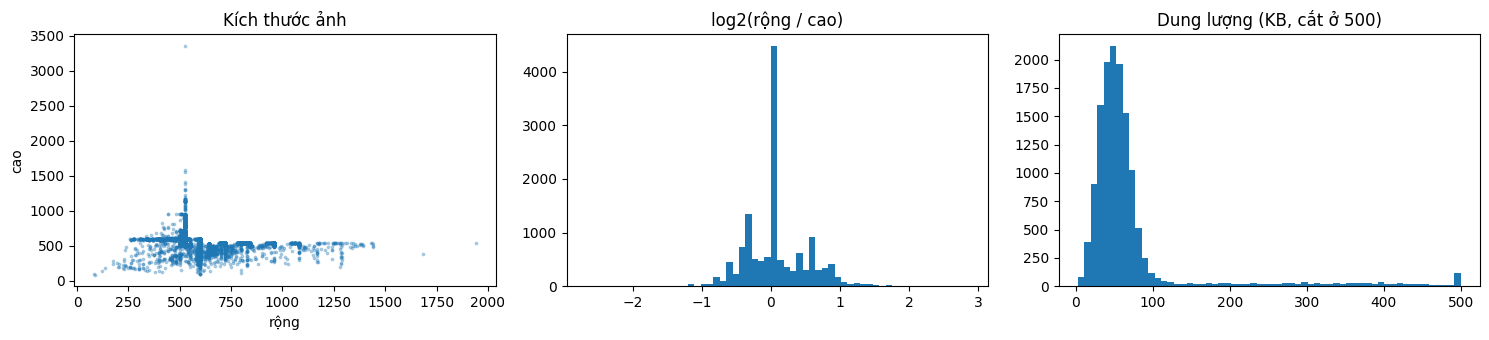

In [12]:
ok["ratio"] = ok["w"] / ok["h"]
display(ok.groupby("split")[["w", "h", "ratio", "KB"]].describe().T.round(2))

small = ok[(ok["w"] < 100) | (ok["h"] < 100)]
extreme = ok[(ok["ratio"] > 3) | (ok["ratio"] < 1 / 3)]
check("không có ảnh quá nhỏ (< 100px)", small.empty, f"{len(small)} ảnh")
# CLIP resize cạnh ngắn rồi center crop hình vuông: ảnh quá dài/quá rộng sẽ bị cắt mất nhiều nội dung
check("không có ảnh tỉ lệ cực đoan (> 3:1)", extreme.empty, f"{len(extreme)} ảnh, CLIP center crop sẽ cắt mất phần lớn ảnh")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].scatter(ok["w"], ok["h"], s=3, alpha=0.3)
axes[0].set_xlabel("rộng")
axes[0].set_ylabel("cao")
axes[0].set_title("Kích thước ảnh")
axes[1].hist(np.log2(ok["ratio"]), bins=60)
axes[1].set_title("log2(rộng / cao)")
axes[2].hist(ok["KB"].clip(upper=500), bins=60)
axes[2].set_title("Dung lượng (KB, cắt ở 500)")
plt.tight_layout()
plt.show()

In [13]:
if HASH_IMAGES:
    dup_img = ok[ok.duplicated("md5", keep=False)]
    check("không có ảnh trùng nội dung (md5)", dup_img.empty,
          f"{len(dup_img)} file thuộc {dup_img['md5'].nunique()} nhóm")
    if not dup_img.empty:
        g = dup_img.groupby("md5")
        cross = g["split"].nunique() > 1
        conflict = dup_img[dup_img["split"] == "train"].groupby("md5")["label"].nunique() > 1
        print(f"nhóm ảnh trùng xuất hiện ở nhiều split: {cross.sum()}")
        print(f"nhóm ảnh trùng trong train có nhãn khác nhau: {conflict.sum()}")
        display(g.agg(n=("image", "size"), splits=("split", lambda s: sorted(set(s))),
                      labels=("label", lambda s: dict(collections.Counter(s.dropna())))).sort_values("n", ascending=False).head(10))

CHÚ Ý không có ảnh trùng nội dung (md5)  (84 file thuộc 42 nhóm)
nhóm ảnh trùng xuất hiện ở nhiều split: 20
nhóm ảnh trùng trong train có nhãn khác nhau: 9


,n,splits,labels
md5,,,
00da95771d8b4acfd8fc07ae83d53ffe,2,"[public_test, train]",{'not-sarcasm': 1}
02d4c77558da1d019d26ed7be9ef91e5,2,[train],"{'not-sarcasm': 1, 'multi-sarcasm': 1}"
0312b356a0229c6defc7e395977448dd,2,"[private_test, public_test]",{}
04bf7bcd0fd9e09fb546e55354f4a559,2,[train],"{'not-sarcasm': 1, 'text-sarcasm': 1}"
130b575cbae98787858d69dbb8e9c880,2,[train],{'not-sarcasm': 2}
179594e5df3d920cacd1b8d1931f3e0b,2,[train],"{'not-sarcasm': 1, 'multi-sarcasm': 1}"
31524686185026ee8c49a682c06b21af,2,"[private_test, public_test]",{}
38804f250162afe5d8938739ec05960c,2,"[private_test, train]",{'multi-sarcasm': 1}
483f1dc21c1ba7a0b0404093b9850ee3,2,[train],{'not-sarcasm': 2}


## 9. Xem mẫu theo nhãn

===== not-sarcasm (6062 mẫu)


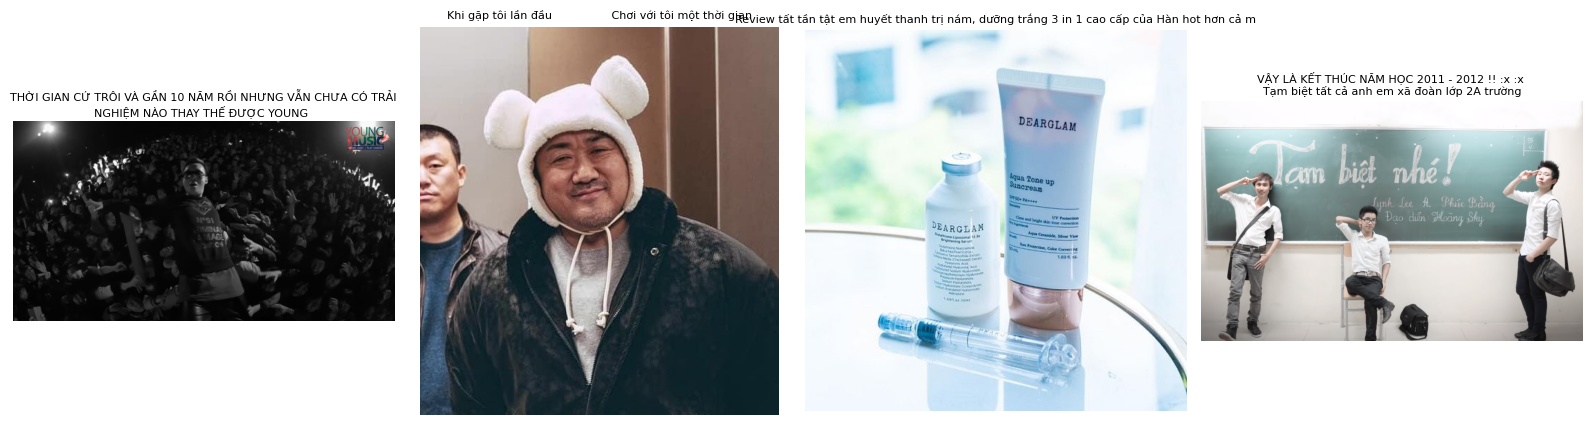

===== text-sarcasm (77 mẫu)


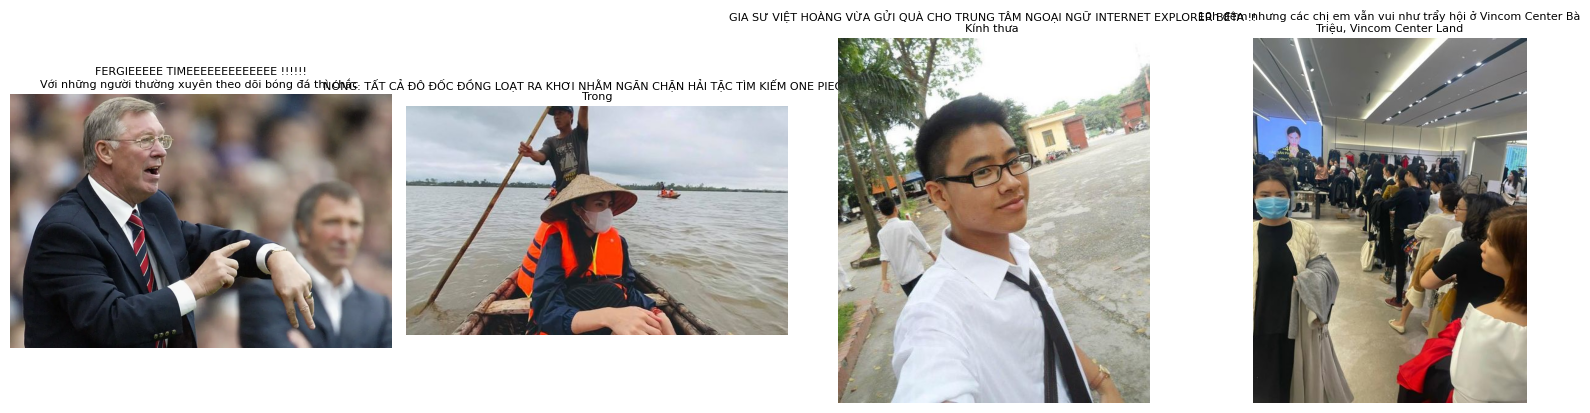

===== image-sarcasm (442 mẫu)


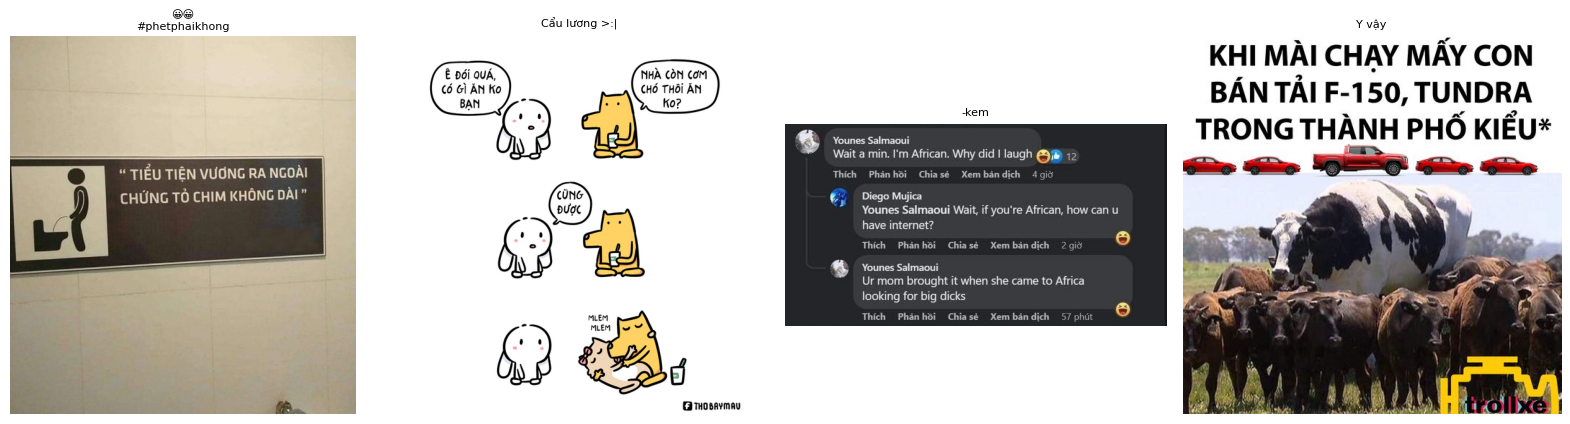

===== multi-sarcasm (4224 mẫu)


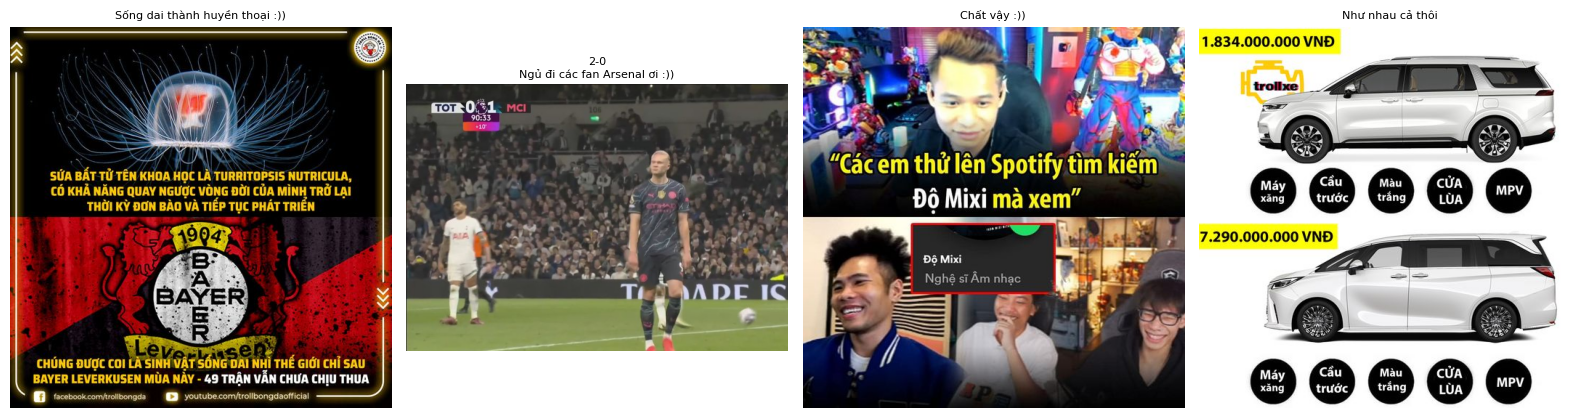

In [14]:
def show(rows, title_fn, ncols=4):
    rows = list(rows)
    nrows = max(1, (len(rows) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.2 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, r in zip(axes.flat, rows):
        try:
            ax.imshow(Image.open(r.image_path).convert("RGB"))
        except Exception:  # noqa: BLE001
            pass
        ax.set_title(title_fn(r), fontsize=8, wrap=True)
    plt.tight_layout()
    plt.show()


train = df_all[(df_all["split"] == "train") & df_all["exists"]]
for label in LABELS:
    subset = train[train["label"] == label]
    print(f"===== {label} ({len(subset)} mẫu)")
    show(subset.sample(min(4, len(subset)), random_state=0).itertuples(),
         lambda r: html.unescape(r.caption)[:90])

caption: '#Interpool\n-Ivan'


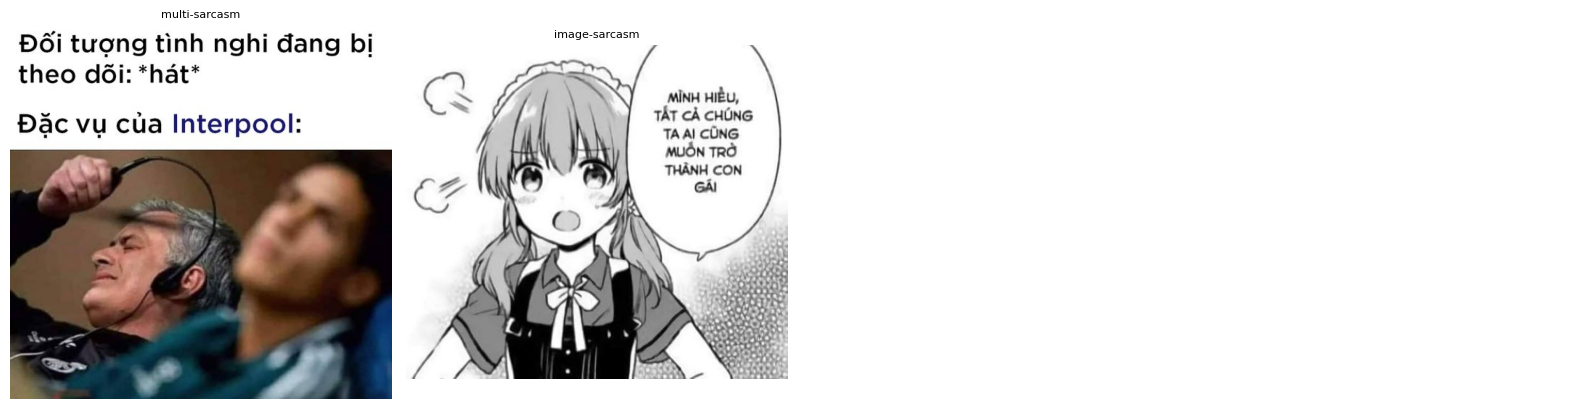

caption: '#interpool'


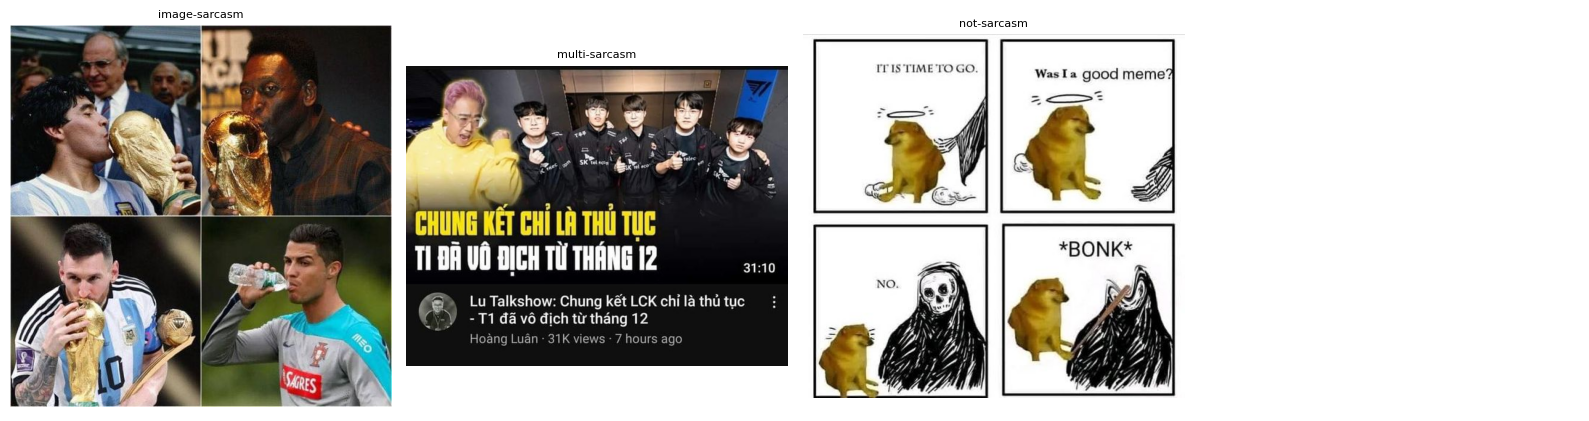

In [15]:
# caption trùng nhưng nhãn khác: đây là các mẫu mà thông tin ảnh quyết định nhãn
conflict_caps = n_labels[n_labels > 1].index[:2]
for cap in conflict_caps:
    rows = train[train["caption"] == cap].drop_duplicates("label")
    print(f"caption: {cap[:100]!r}")
    show(rows.head(4).itertuples(), lambda r: r.label)

## 10. Tổng kết và đối chiếu với config

In [16]:
summary_df = pd.DataFrame(checks)
display(summary_df.style.apply(
    lambda row: ["background-color: #fde2e1" if row["kết quả"] != "OK" else ""] * len(row), axis=1))

print("\nGiá trị cần có trong configs/base.yaml:")
print(f"  paths.kaggle.data_dir: {data_dir}" if str(data_dir).startswith("/kaggle") else f"  paths.local.data_dir: {data_dir}")
for split, (json_name, image_dir) in SPLITS.items():
    if split in dfs:
        print(f"  {split:13s} {json_name:28s} {image_dir}")

report = {
    "data_dir": str(data_dir),
    "sizes": {s: len(df) for s, df in dfs.items()},
    "label_counts": counts.to_dict(),
    "checks": checks,
}
(OUT_DIR / "dataset_check.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nđã lưu", OUT_DIR / "dataset_check.json")

,kiểm tra,kết quả,chi tiết
0,có file vimmsd-train.json,OK,
1,train: mọi mẫu có đủ image/caption/label,OK,"{('caption', 'image', 'label'): 10805}"
2,có file vimmsd-public-test.json,OK,
3,public_test: mọi mẫu có đủ image/caption/label,OK,"{('caption', 'image', 'label'): 1413}"
4,có file vimmsd-private-test.json,OK,
5,private_test: mọi mẫu có đủ image/caption/label,OK,"{('caption', 'image', 'label'): 1504}"
6,train: id không trùng,OK,
7,train: không có nhãn rỗng,OK,0 mẫu rỗng
8,train: nhãn thuộc 4 lớp đã biết,OK,
9,public_test: không có nhãn (label = null),OK,{None: 1413}



Giá trị cần có trong configs/base.yaml:
  paths.kaggle.data_dir: /kaggle/input/datasets/hhhoang/vimmsd-dataset
  train         vimmsd-train.json            training-images/train-images
  public_test   vimmsd-public-test.json      public-test-images/dev-images
  private_test  vimmsd-private-test.json     private-test-images/test-images

đã lưu /kaggle/working/dataset_check.json
